In [2]:
import arcpy

# 1. 設定環境與參數
# 請替換為你的檔案路徑
polygon_layer = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb\k2b_2508_corals"
dem_raster = r"D:\SfM_coral_reefs_product\KaneoheBay\2025\k2b\HW_k2b_2508_DEM_32604_05mm.tif"

# 檢查 3D Analyst 授權
if arcpy.CheckExtension("3D") == "Available":
    arcpy.CheckOutExtension("3D")
else:
    raise Exception("需要 3D Analyst 擴展模組授權。")

try:
    print("正在計算 3D 表面積...")
    
    # 2. 執行 Add Surface Information
    # "SURFACE_AREA" 會生成一個名為 S_AREA 的欄位
    arcpy.ddd.AddSurfaceInformation(
        in_feature_class=polygon_layer,
        in_surface=dem_raster,
        out_property="SURFACE_AREA",
        method="LINEAR" # 也可以選擇 NATURAL_NEIGHBORS
    )

    # 3. 處理欄位名稱：將 S_AREA 轉換為 Shape_Area_3D
    # 先檢查 Shape_Area_3D 是否已存在，若無則建立
    fields = [f.name for f in arcpy.ListFields(polygon_layer)]
    target_field = "Shape_Area_3D"
    
    if target_field not in fields:
        arcpy.management.AddField(polygon_layer, target_field, "DOUBLE")

    # 將 S_AREA 的值複製到 Shape_Area_3D，並刪除暫存的 S_AREA
    arcpy.management.CalculateField(polygon_layer, target_field, "!S_Area!", "PYTHON3")
    arcpy.management.DeleteField(polygon_layer, "S_Area")

    print(f"成功！結果已儲存在 {target_field} 欄位中。")

except Exception as e:
    print(f"發生錯誤: {e}")

finally:
    # 歸還授權
    arcpy.CheckInExtension("3D")

正在計算 3D 表面積...
發生錯誤: ERROR 000539: Invalid field S_Area
Failed to execute (CalculateField).



<>:82: SyntaxWarning: invalid escape sequence '\l'
<>:83: SyntaxWarning: invalid escape sequence '\l'
C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp21892/xpython_21892/1799645302.py:82: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f"$\log_{{10}}$ 2D Projected Area ({field_x})", fontsize=12)
C:/Users/keelu/AppData/Local/Temp/ArcGISProTemp21892/xpython_21892/1799645302.py:83: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel(f"$\log_{{10}}$ 3D Surface Area ({field_y})", fontsize=12)



                地形類別分析表 (Log-Log Scale)                
-----------------------------------------------------------------
Form 類別  樣本數 (N)  Log-Log 相關係數 (r)
   br     239          0.9821     
   cb     122          0.9887     
   di     340          0.9398     
   en     294          0.9834     
   fr       5          0.9517     
   ma      44          0.9845     
   su       8          0.9675     



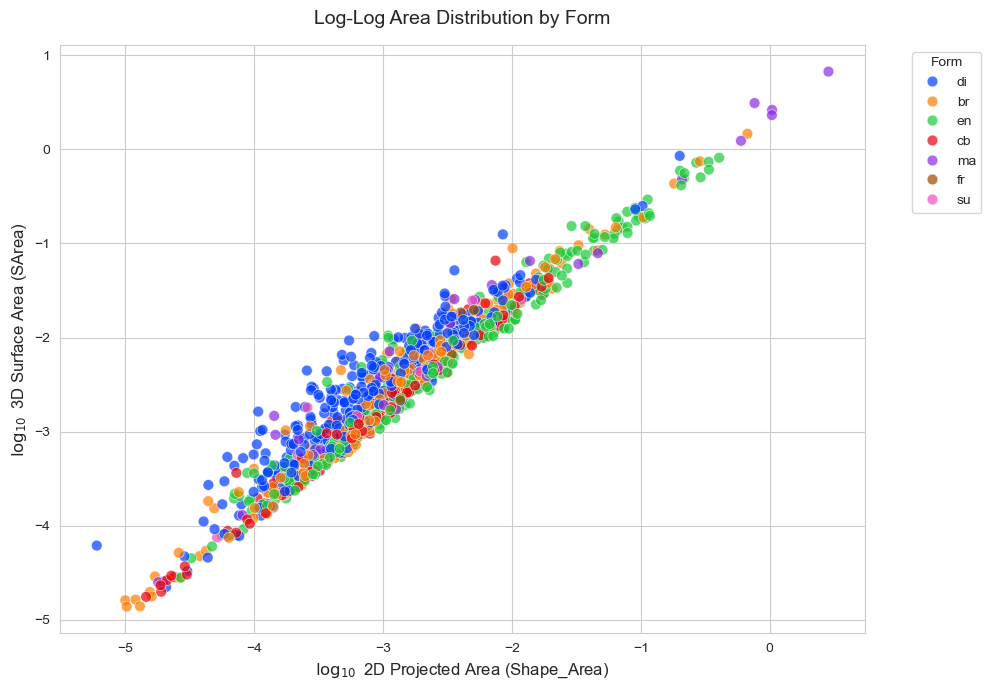

In [7]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 參數設定
input_layer = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Hawaii.gdb\k2b_2508_corals" 
field_x = "Shape_Area"
field_y = "SArea"
group_field = "Form"

# 2. 獲取 Domain 轉換字典
def get_domain_map(layer, field_name):
    desc = arcpy.Describe(layer)
    workspace = desc.path
    fields = arcpy.ListFields(layer)
    domain_name = next((f.domain for f in fields if f.name == field_name), "")
    if not domain_name: return None
    domains = arcpy.da.ListDomains(workspace)
    for d in domains:
        if d.name == domain_name: return d.codedValues 
    return None

domain_map = get_domain_map(input_layer, group_field)

# 3. 提取數據並轉換為 Pandas DataFrame
fields = [field_x, field_y, group_field]
data = [row for row in arcpy.da.SearchCursor(input_layer, fields)]
df = pd.DataFrame(data, columns=fields)

# 4. 數據清洗與 Log 轉換
# 排除小於或等於 0 的值（Log10 必須大於 0）
df = df[(df[field_x] > 0) & (df[field_y] > 0)].copy()

# 轉換 Domain 代碼
if domain_map:
    df[group_field] = df[group_field].map(domain_map).fillna(df[group_field])

# 計算 Log10 數值供統計使用
df['log_x'] = np.log10(df[field_x])
df['log_y'] = np.log10(df[field_y])

# 5. 計算統計資訊 (基於 Log 轉換後的數據計算相關性)
stats_list = []
for name, group in df.groupby(group_field):
    corr_val = group['log_x'].corr(group['log_y']) if len(group) > 1 else 0
    stats_list.append({
        "Form 類別": name,
        "樣本數 (N)": len(group),
        "Log-Log 相關係數 (r)": round(corr_val, 4)
    })

stats_df = pd.DataFrame(stats_list)

# 6. 輸出表格
print("\n" + "="*65)
print(f"{'地形類別分析表 (Log-Log Scale)':^55}")
print("-" * 65)
print(stats_df.to_string(index=False, justify='center'))
print("="*65 + "\n")

# 7. 繪圖 (Log-Log 散佈圖，無回歸線)
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# 使用 scatterplot，這不會畫出回歸趨勢線
scatter = sns.scatterplot(
    data=df, 
    x='log_x', 
    y='log_y', 
    hue=group_field, 
    palette="bright", 
    s=60, 
    alpha=0.7,
    edgecolor="w",
    linewidth=0.5
)

# 設定標籤與標題
plt.title(f"Log-Log Area Distribution by {group_field}", fontsize=14, pad=15)
plt.xlabel(f"$\log_{{10}}$ 2D Projected Area ({field_x})", fontsize=12)
plt.ylabel(f"$\log_{{10}}$ 3D Surface Area ({field_y})", fontsize=12)

# 圖例優化：放在圖外避免擋住點位
plt.legend(title=group_field, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# 直接顯示
plt.show()